In [38]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from langdetect import detect, LangDetectException

In [39]:
from src.baseline import config, constants

In [40]:
embeddings_path = config.MODEL_DIR / constants.NOMIC_EMBEDDINGS_FILENAME

In [41]:
embeddings_dict = joblib.load(embeddings_path)

In [42]:
descriptions_df = pd.read_csv('/Users/daniilogorodnikov/PycharmProjects/nto-ai-25-26-team-baseline/data/raw/book_descriptions.csv')

In [43]:
book_ids = list(embeddings_dict.keys())
embeddings = np.array(list(embeddings_dict.values()))

In [44]:
unique_books = descriptions_df[[constants.COL_BOOK_ID, constants.COL_DESCRIPTION]].drop_duplicates(subset=[constants.COL_BOOK_ID])
unique_books[constants.COL_DESCRIPTION] = unique_books[constants.COL_DESCRIPTION].fillna("")

In [45]:
languages = []
for desc in tqdm(unique_books[constants.COL_DESCRIPTION]):
    try:
        if desc.strip():  # Skip empty descriptions
            lang = detect(desc)
        else:
            lang = 'unknown'
    except LangDetectException:
        lang = 'unknown'
    languages.append(lang)

100%|██████████| 55784/55784 [01:50<00:00, 504.59it/s]


In [46]:
unique_books['language'] = languages

In [47]:
language_map = dict(zip(unique_books[constants.COL_BOOK_ID], unique_books['language']))
book_languages = [language_map[book_id] for book_id in book_ids]

In [48]:
label_encoder = LabelEncoder()
numerical_labels = label_encoder.fit_transform(book_languages)

In [49]:
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

In [50]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_scaled)

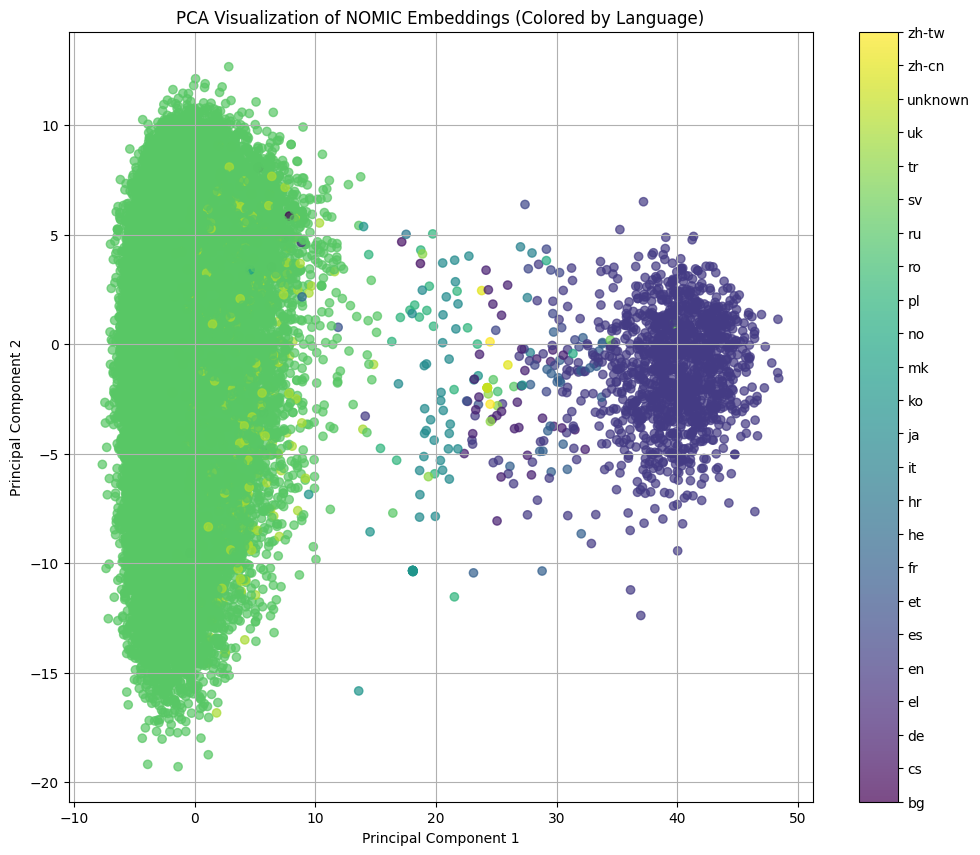

In [51]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=numerical_labels, cmap='viridis', alpha=0.7)
plt.title('PCA Visualization of NOMIC Embeddings (Colored by Language)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(len(label_encoder.classes_)), format=plt.FuncFormatter(lambda i, *args: label_encoder.classes_[int(i)]))
plt.grid(True)
plt.savefig('pca_visualization_colored.png')  # Save the plot to a file
plt.show()  # Display the plot if running in an interactive environment

In [52]:
language_counts = unique_books['language'].value_counts()

In [53]:
top_n = 10
top_languages = language_counts.head(top_n)

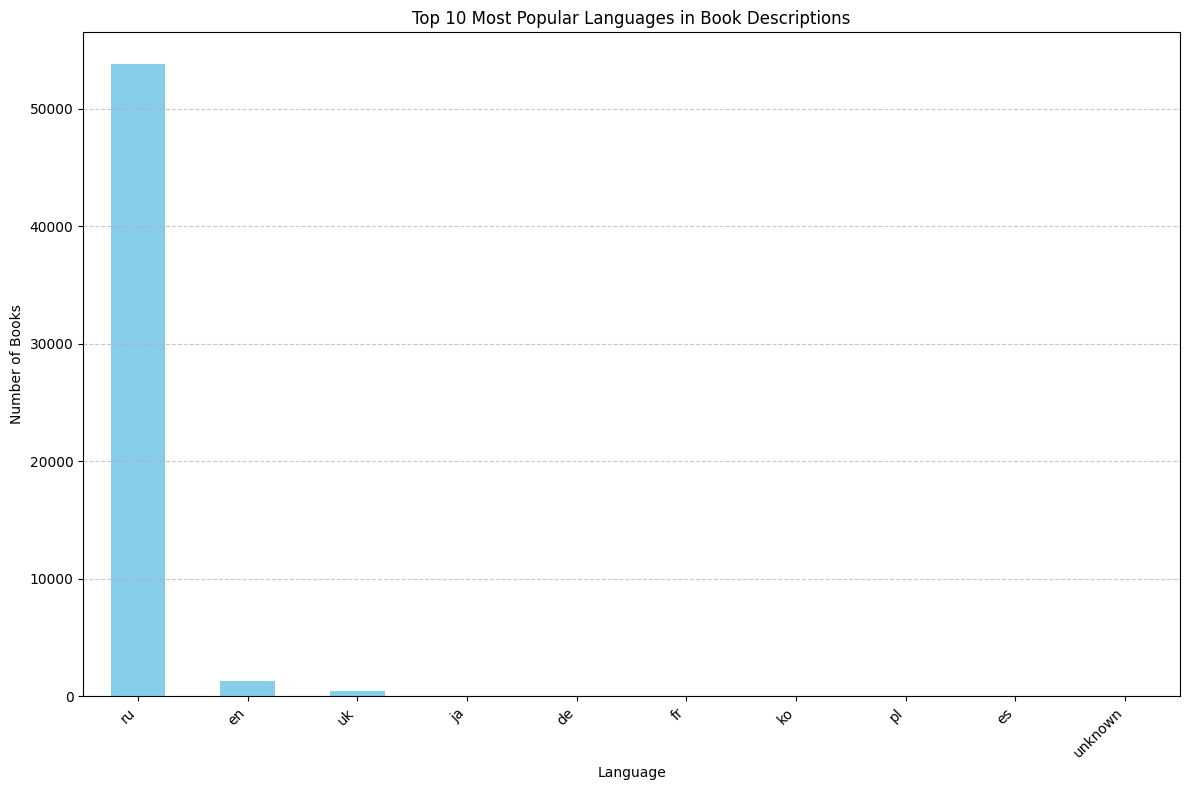

In [54]:
plt.figure(figsize=(12, 8))
top_languages.plot(kind='bar', color='skyblue')
plt.title(f'Top {top_n} Most Popular Languages in Book Descriptions')
plt.xlabel('Language')
plt.ylabel('Number of Books')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_languages_bar_graph.png')  # Save the plot to a file
plt.show()  # Display the plot if running in an interactive environment